In [2]:
import jax
import jax.numpy as jnp
from sklearn.preprocessing import normalize
import math
import matplotlib.pyplot as plt
import numpy as np
import random
np.random.seed()

In [3]:
delta = 0.3
C_m = 5

# Step 1: create data

In [4]:
def create_data(n,d):
    #generates data for neural netork

    X = normalize(np.random.normal(size=(n,d)), axis=1, norm='l2')
    Y = np.random.normal(size=n)
    return(X,Y)
    
X,Y = create_data(2,3)
print(X)
print(Y)

[[-0.54856665  0.58066724 -0.6015814 ]
 [-0.84050608 -0.51157416  0.1784416 ]]
[0.1529522  1.73893202]


In [5]:
def create_weights(m,d):
    #generates initial weights for neural network
    a = np.random.choice(np.array([int(-1),int(1)]),size = m)
    W = np.random.normal(size=(m,d))
    return(a,W)

a,W = create_weights(10,5)
print(a)
print(W[3])
    

[ 1 -1  1  1  1  1 -1 -1  1  1]
[ 0.29729772 -1.89588885  1.8832905   0.75383454 -0.82618269]


# Step 2: choose values of beta and compute corresponding m

In [6]:
def m_beta(beta,n,delta,C_m):
    return(((C_m*n**5)/(delta**2 * beta**2))*math.log((n)/(delta)))

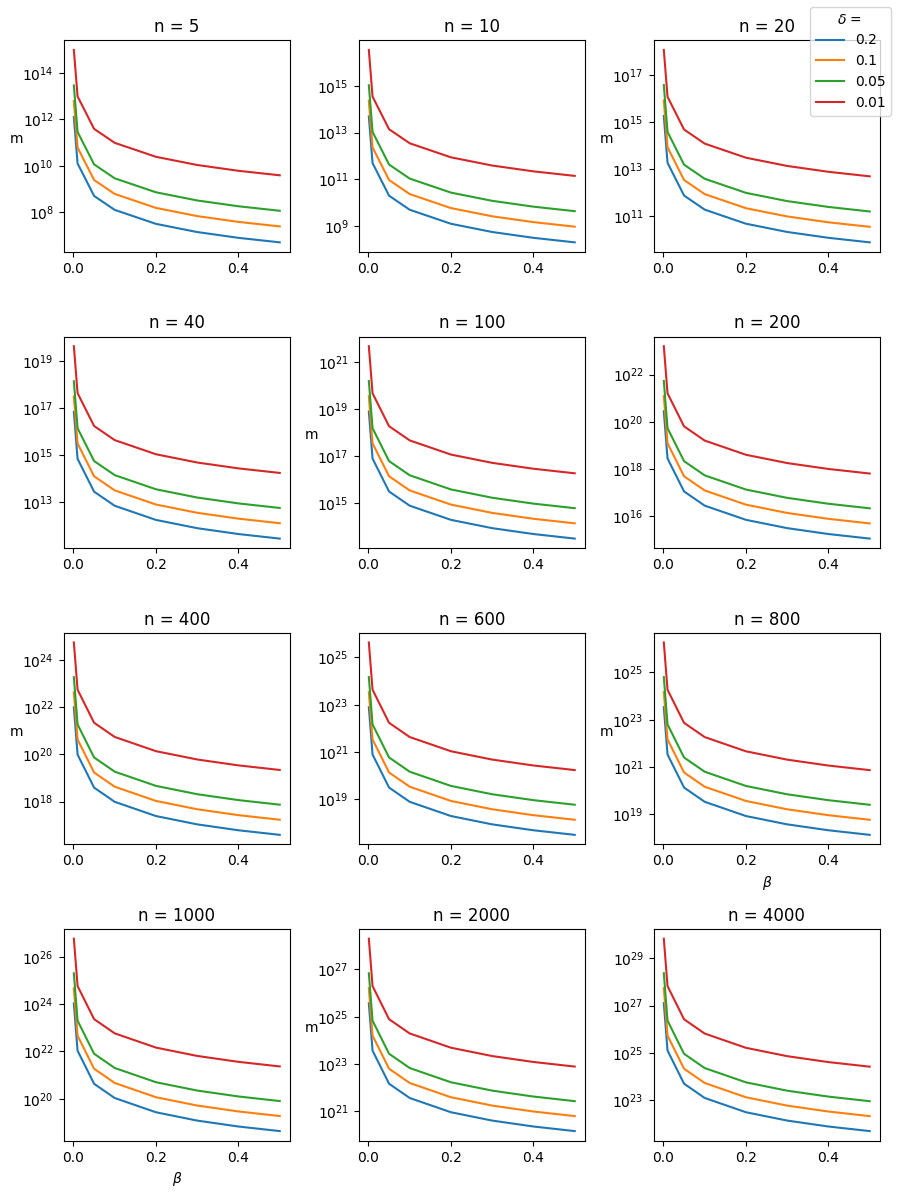

In [7]:
nrows = 4
ncols = 3
fig, axs = plt.subplots(nrows,ncols,figsize=(ncols*3,nrows*3))
betas = [0.5,0.4,0.3,0.2,0.1,0.05,0.01,0.001]
deltas = [0.2,0.1,0.05,0.01]
ns = [5,10,20,40,100,200,400,600,800,1000,2000,4000,6000,8000,1000]
for i in range(nrows*ncols):
    n = ns[i]
    for delta in deltas:
        axs[i//ncols,i%ncols].plot(betas,[m_beta(beta,n,delta,C_m) for beta in betas])
        axs[i//ncols,i%ncols].set_yscale("log")
    axs[i//ncols,i%ncols].set_title("n = " + str(n))
    if i%2 == 0:
        axs[i//ncols,i%ncols].set_ylabel("m",rotation=0)
    if i//2 == nrows:
        axs[i//ncols,i%ncols].set_xlabel("$\\beta$")
fig.legend(deltas,title="$\\delta$ = ")
plt.tight_layout()
plt.show()

# New idea: animate behaviour of shallow network with few nodes

In [50]:
def sigma_beta(x,b):
    if abs(x) <= b:
        return 1/(2*b)
    else:
        return 0
    
def compute_loss(v1,v2):
    res = 0
    for i in range(len(v1)):
        res += (v1[i]-v2[i])**2
    return(0.5*math.sqrt(res))

def NTK_output(a,W,X):
    f = []
    for j in range(len(X)):
        res = 0
        for r in range(len(W)):
            if np.dot(W[r],X[j]) >= 0:
                res += a[r]
        f += [res/(math.sqrt(len(W)))]
    return(f)
    
class NTK_shallow:
    def __init__(self,n,d,m,b,train_a=True):
        #store given variables
        self.n = n
        self.d = d
        self.m = m
        self.b = b
        self.train_a = train_a

        #generate random data
        self.X,self.y = create_data(n,d)

        #initialise weights of the network
        self.a, self.W = create_weights(self.m,self.d)

        #compute current value of f
        self.f = NTK_output(self.a,self.W,self.X)

        #create object to store generated frames
        self.frames = [np.copy(self.W)]

        #compute initial loss
        self.losses = [compute_loss(self.f,self.y)]

        #store outer weights
        self.outer = [np.copy(self.a)]

        #We want to study if the outer weights or inner weights contribute more to lowering the loss at early vs late stages of training
        self.loss_diffs = []
        
    def grad_w(self,r):
        res = np.asarray([0 for x in range(self.d)])
        for j in range(self.n):
            mult_fact = (self.f[j] - self.y[j]) * self.a[r] * sigma_beta(np.dot(self.W[r],self.X[j]),self.b)
            res = res + mult_fact * self.X[j]
        return(res/(math.sqrt(self.m)))
    
    def grad_a(self,r):
        res = 0
        for j in range(self.n):
            if np.dot(self.W[r],self.X[j]) >= 0:
                res += (self.f[j] - self.y[j])
        return(res/(math.sqrt(self.m)))

    def update_weights(self,t):
        if self.train_a:
            prev_W = np.copy(self.W)
            prev_a = np.copy(self.a)
            self.a = np.copy([self.a[r]-self.grad_a(r)*t for r in range(self.m)])
        
        for r in range(self.m):
            self.W[r] = np.copy(self.W[r] - self.grad_w(r)*t)
        
        self.f = NTK_output(self.a,self.W,self.X)
        self.losses.append(compute_loss(self.f,self.y))
        if self.train_a:
            self.loss_diffs.append([compute_loss(NTK_output(prev_a,self.W,self.X),self.y)-self.losses[-2],compute_loss(NTK_output(self.a,prev_W,self.X),self.y)-self.losses[-2]])

    def gen_frames(self,t,num):
        for i in range(num):
            self.update_weights(t)
            self.frames.append(np.copy(self.W))
            self.outer.append(np.copy(self.a))

In [107]:
def plot_vector(x,y,color):
    plt.plot([0,x],[0,y],color = "black")
    plt.plot([0.95*x+0.05*y,x],[0.95*y-0.05*x,y],color = "black")
    plt.plot([0.95*x-0.05*y,x],[0.95*y+0.05*x,y],color = "black")
def plot_weight(NTK_inst,r):
    W_x = [x[r][0] for x in NTK_inst.frames]
    W_y = [x[r][1] for x in NTK_inst.frames]
    plt.plot(W_x,W_y)
    
def train_plot(n,d,m,b,t,num,train_a = True):
    NTk_inst = NTK_shallow(n,d,m,b,train_a)
    NTk_inst.gen_frames(t,num)
    
    if d == 2:
        for i in range(NTk_inst.n):
            plot_vector(NTk_inst.X[i][0],NTk_inst.X[i][1],"black")
        for r in range(NTk_inst.m):
            plot_weight(NTk_inst,r)

        x_max = max(max([max([x[r][0] for x in NTk_inst.frames]) for r in range(NTk_inst.m)]),NTk_inst.X[0][0],NTk_inst.X[1][0])
        y_max = max(max([max([x[r][1] for x in NTk_inst.frames]) for r in range(NTk_inst.m)]),NTk_inst.X[0][1],NTk_inst.X[1][1])
        x_min = min(min([min([x[r][0] for x in NTk_inst.frames]) for r in range(NTk_inst.m)]),NTk_inst.X[0][0],NTk_inst.X[1][0])
        y_min = min(min([min([x[r][1] for x in NTk_inst.frames]) for r in range(NTk_inst.m)]),NTk_inst.X[0][1],NTk_inst.X[1][1])
        plt.xlim([x_min-0.5, x_max+0.5])
        plt.ylim([y_min-0.5, y_max+0.5])
        ax = plt.gca()
        ax.set_aspect('equal')
        plt.show()
    
    if not train_a:
        plt.plot([i for i in range(len(NTk_inst.losses))],NTk_inst.losses)
        plt.xlabel("Iteration")
        plt.ylabel("Loss")
        plt.show()
    if train_a:
        fig, ax = plt.subplots(1,3,figsize=(13,4))

        loss_diffs_a = [x[0] for x in NTk_inst.loss_diffs]
        loss_diffs_W = [x[1] for x in NTk_inst.loss_diffs]

        ax[0].plot([i for i in range(len(NTk_inst.losses))],NTk_inst.losses)
        ax[0].set_xlabel("Iteration")
        ax[0].set_ylabel("Loss")

        ax[1].plot([i for i in range(len(NTk_inst.loss_diffs))],np.cumsum(loss_diffs_a),label="Outer weights")
        ax[1].plot([i for i in range(len(NTk_inst.loss_diffs))],np.cumsum(loss_diffs_W),label="Inner weights")
        ax[1].set_xlabel("Iteration")
        ax[1].set_ylabel("Cumulated loss difference")

        
        ax[2].plot([i for i in range(len(NTk_inst.loss_diffs))],loss_diffs_a,label="Outer weights")
        ax[2].plot([i for i in range(len(NTk_inst.loss_diffs))],loss_diffs_W,label="Inner weights")
        ax[2].legend()
        ax[2].set_xlabel("Iteration")
        ax[2].set_ylabel("Loss difference")

        fig.suptitle("n = " + str(n) + " | " + "d = " + str(d) + " | " + "m = " + str(m) + " | " + "$\\beta$" + " = " + str(b))
        plt.tight_layout()
        plt.show()

        
        #for i in range(NTk_inst.m):
        #    plt.plot([i for i in range(len(NTk_inst.losses))],[x[i] for x in NTk_inst.outer])
        #    plt.xlabel("Iteration")
        #    plt.ylabel(str(i) + "th outer weight")
        #    plt.show()
        #    if i == 4:
        #        break



/tmp/ipykernel_2046/3016535769.py:57: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  fig.legend([l1, l2], labels=["Outer weights","Inner weights"],loc="upper right")


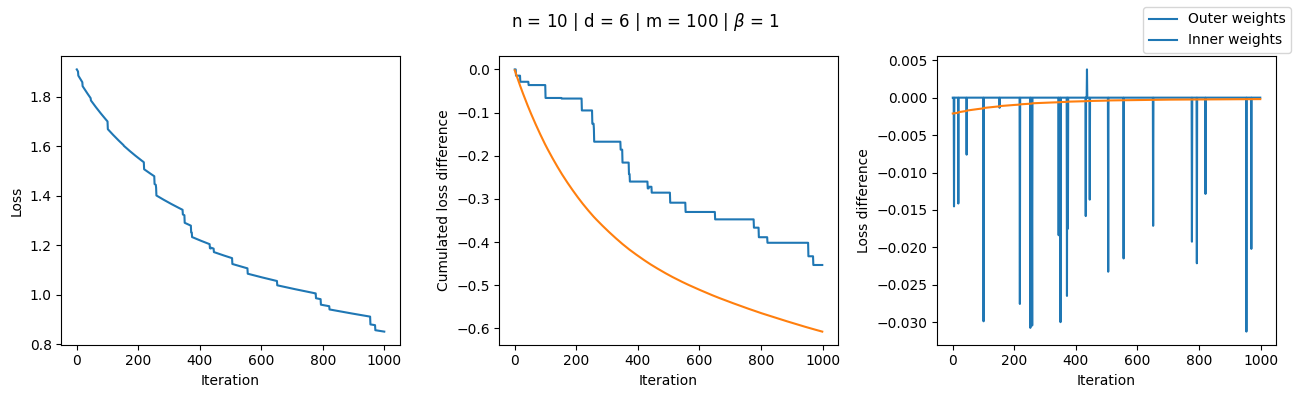

In [ ]:
train_plot(n=10,d=6,m=100,b=1,t=0.001,num=1000,train_a=True)

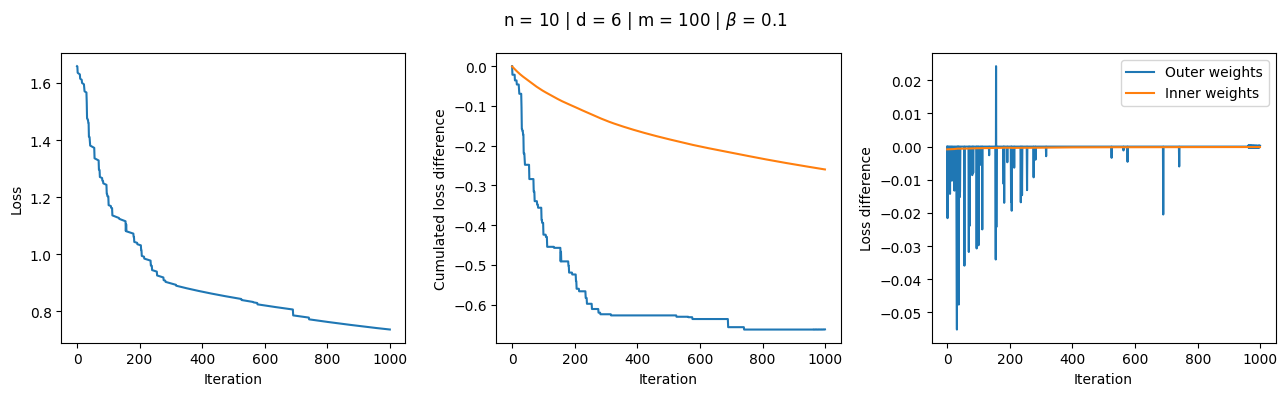

In [97]:
train_plot(n=10,d=6,m=100,b=0.1,t=0.001,num=1000,train_a=True)

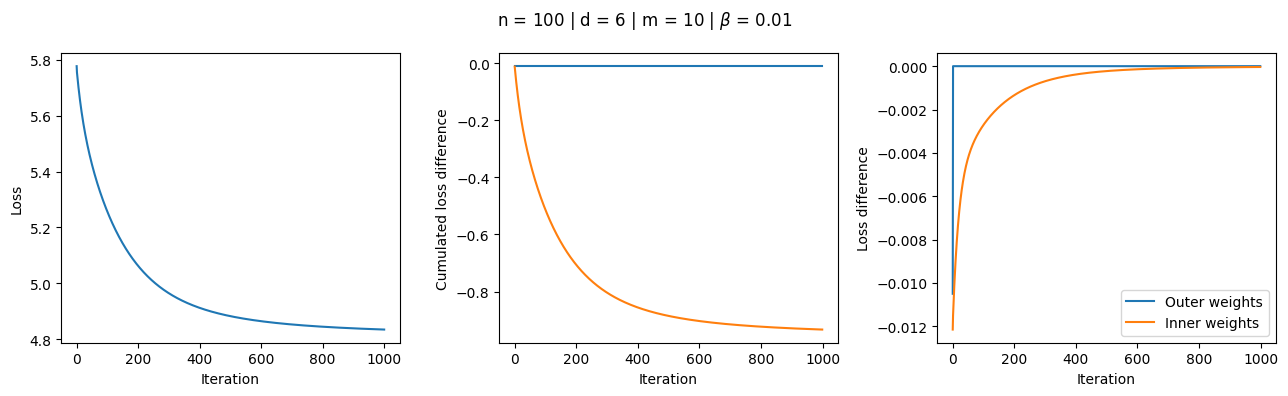

In [98]:
train_plot(n=100,d=6,m=10,b=0.01,t=0.001,num=1000,train_a=True)

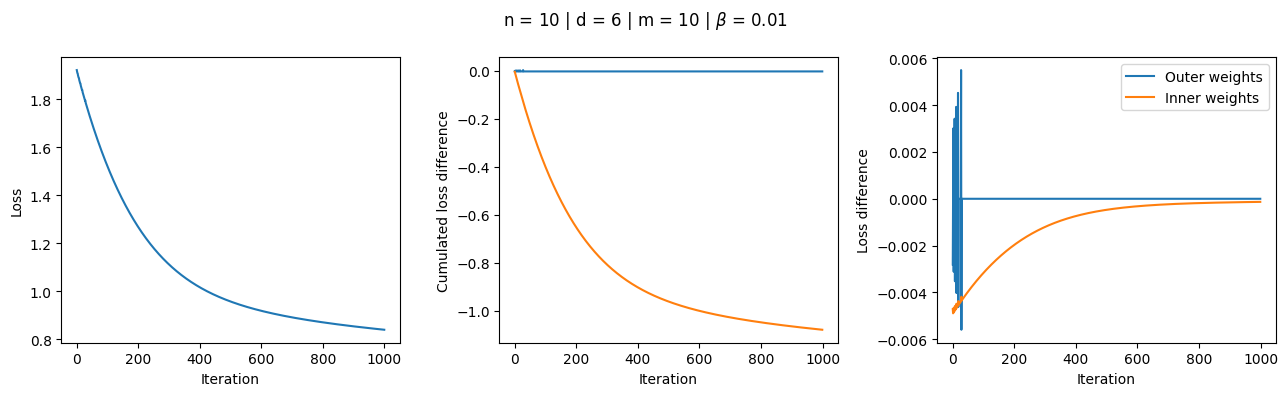

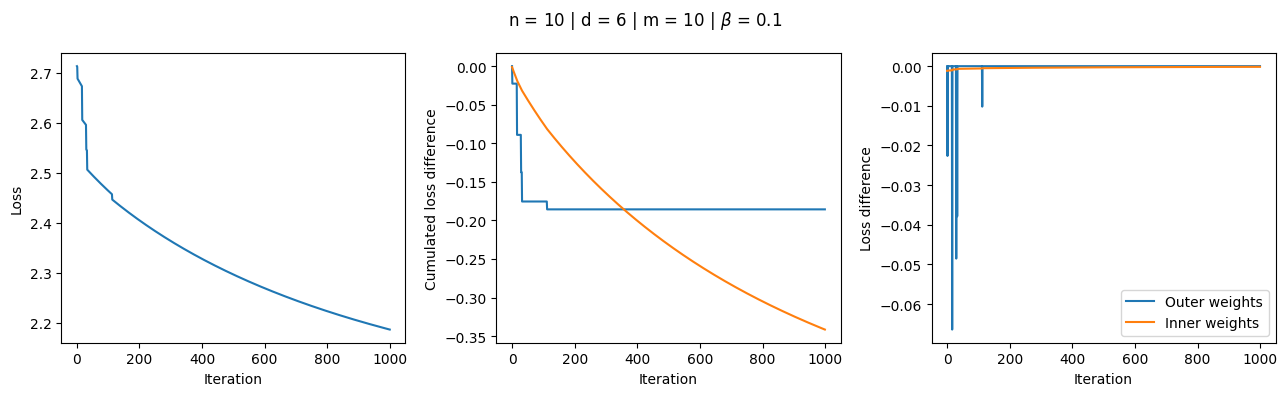

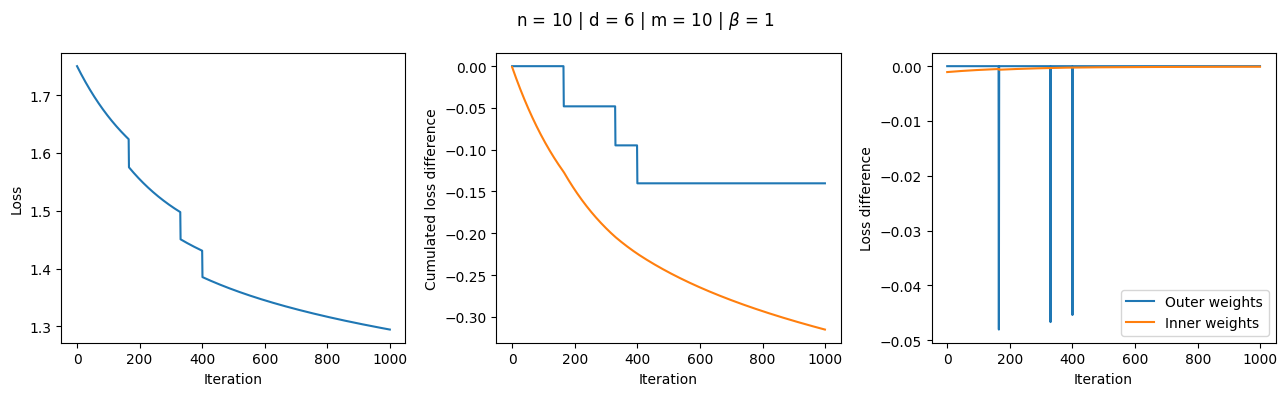

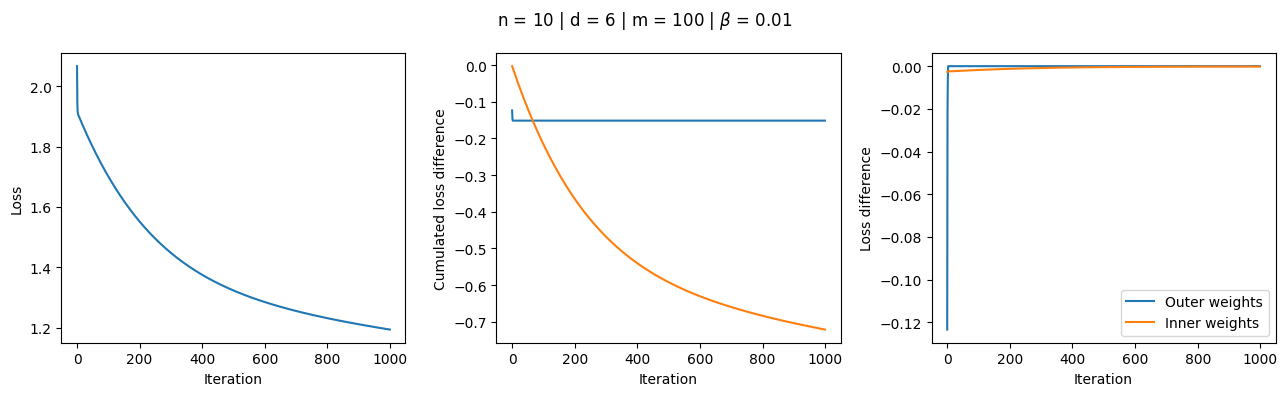

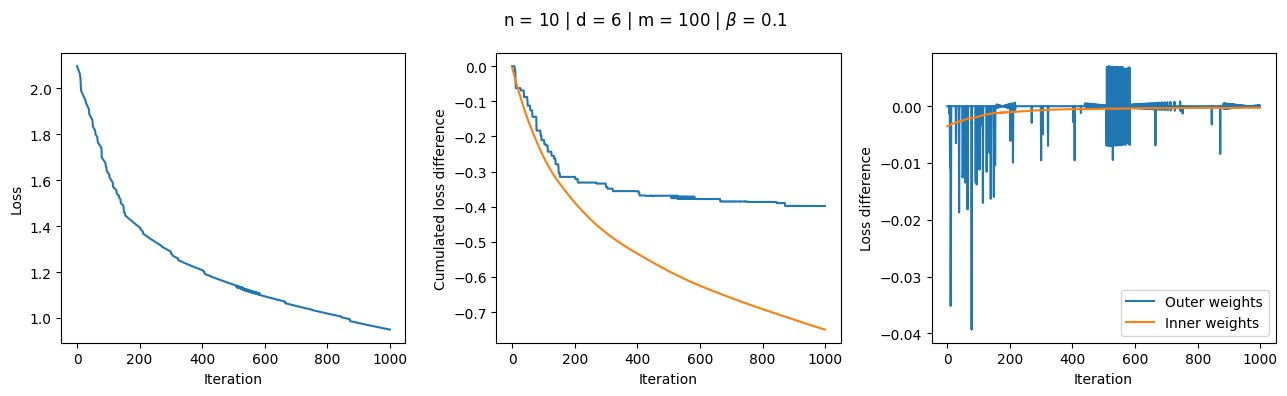

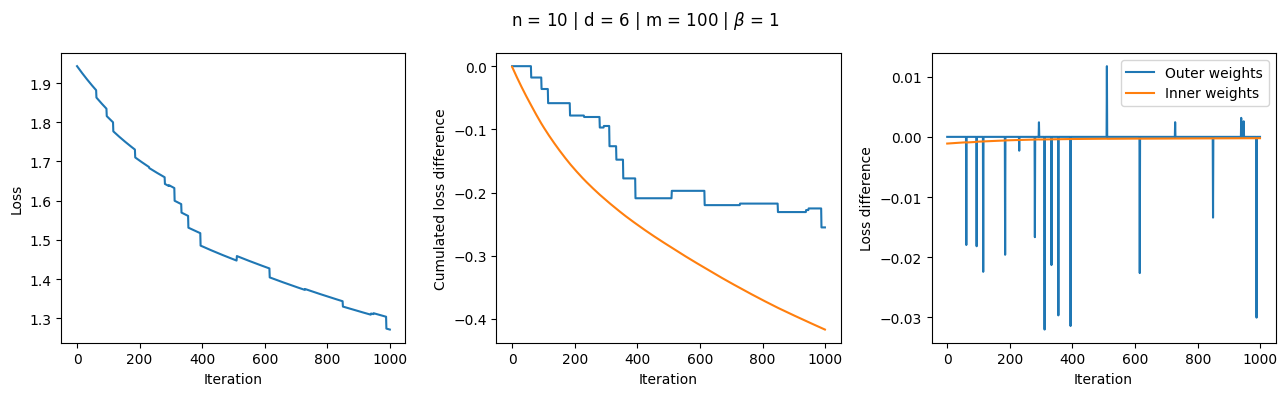

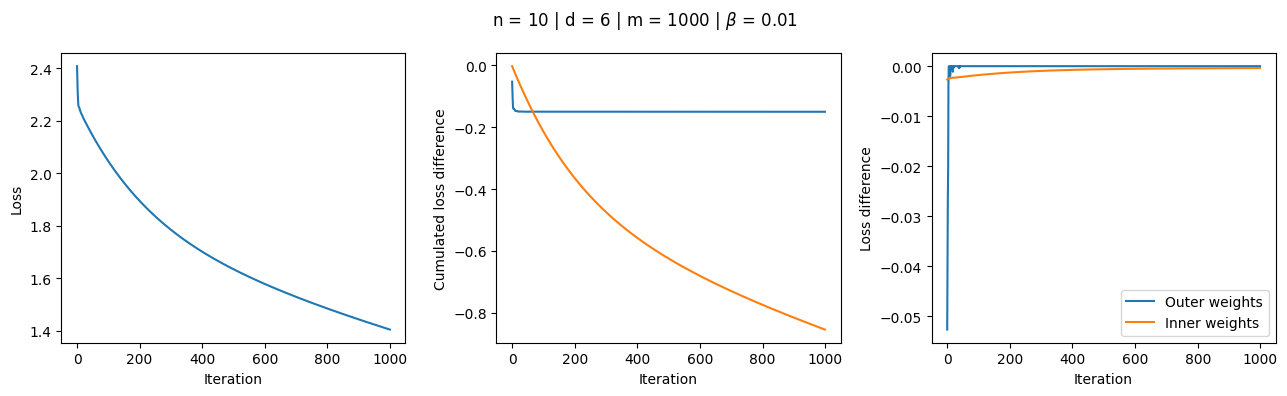

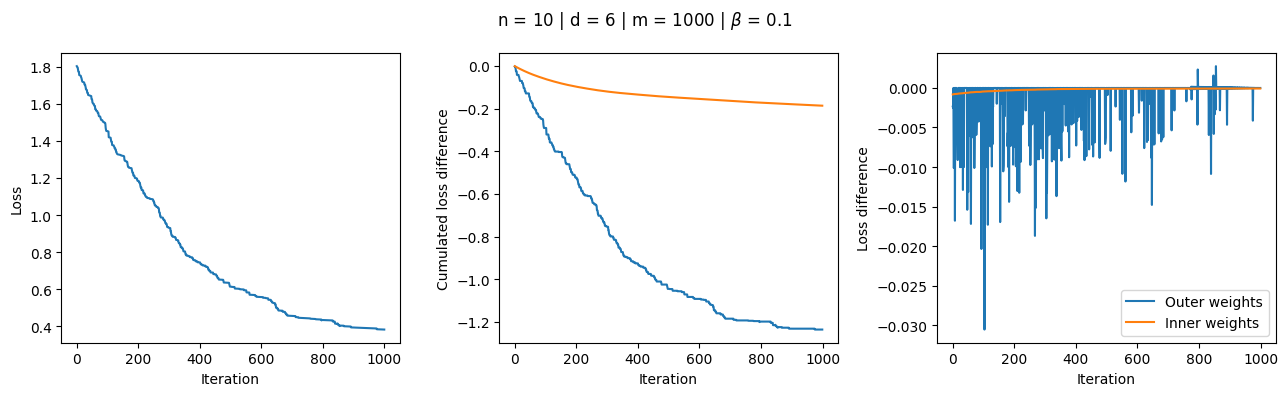

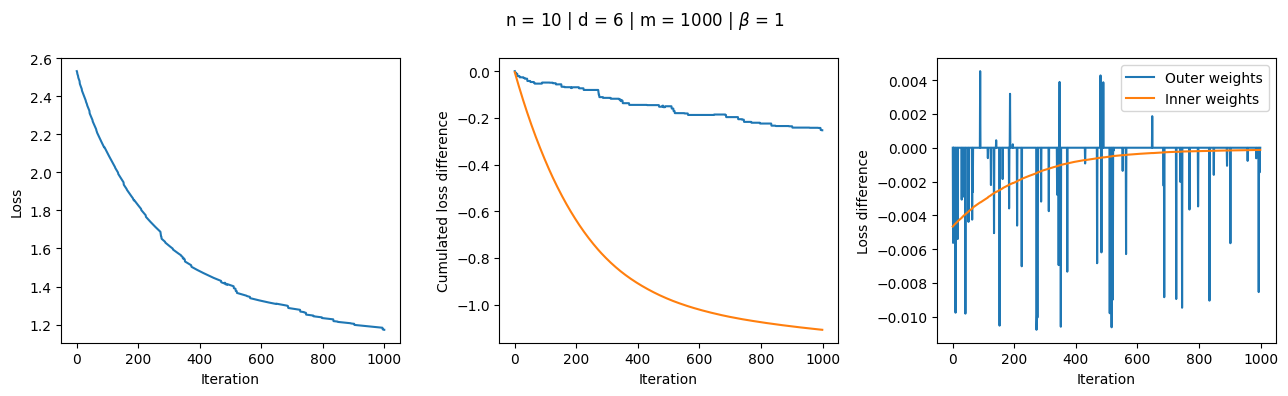

In [109]:
for m in [10,100,1000]:
    for b in [0.01,0.1,1]:
        train_plot(n=10,d=6,m=m,b=b,t=0.001,num=1000,train_a=True)